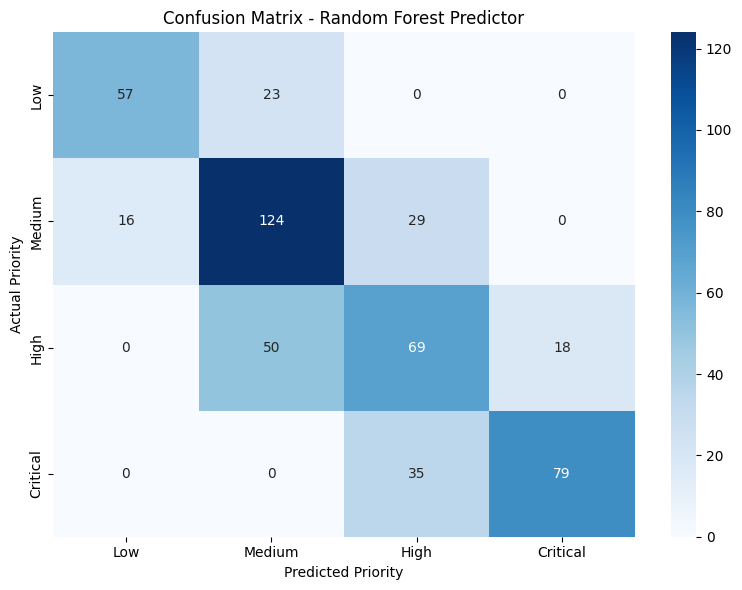


Processing complete! Downloading assets...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from google.colab import files

# 1. GENERATE SYNTHETIC DATASET (WITH BRANCH LOCATIONS)
np.random.seed(42)
n_samples = 2500

departments = ['HR', 'Finance', 'IT', 'Sales', 'Marketing', 'Operations']
categories = ['Software', 'Hardware', 'Network', 'Access/Login', 'Security']
devices = ['Laptop', 'Desktop', 'Mobile', 'Printer', 'Server', 'None']
locations = ['Kandy', 'Colombo']  # Added your exact branches

data = {
    'Department': np.random.choice(departments, n_samples),
    'Issue_Category': np.random.choice(categories, n_samples),
    'Device_Type': np.random.choice(devices, n_samples),
    'Affected_Users': np.random.randint(1, 50, n_samples),
    'Business_Critical': np.random.choice(['Yes', 'No'], n_samples, p=[0.2, 0.8]),
    'Office_Location': np.random.choice(locations, n_samples)  # Included in data pipeline
}
df = pd.DataFrame(data)

# Logical rule-based mapping to determine ground-truth priority
def assign_priority(row):
    score = 0
    if row['Business_Critical'] == 'Yes': score += 4
    if row['Affected_Users'] > 20: score += 3
    elif row['Affected_Users'] > 5: score += 1
    if row['Issue_Category'] in ['Network', 'Security']: score += 2

    score += np.random.randint(-1, 2) # Noise variance
    if score >= 6: return 'Critical'
    elif score >= 4: return 'High'
    elif score >= 2: return 'Medium'
    else: return 'Low'

df['Priority'] = df.apply(assign_priority, axis=1)

# 2. DATA PREPROCESSING & LABEL ENCODING
encoders = {}
categorical_cols = ['Department', 'Issue_Category', 'Device_Type', 'Business_Critical', 'Office_Location']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop('Priority', axis=1)
y = df['Priority']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. MODEL IMPLEMENTATION & COMPARISON
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average='weighted')
    results.append({'Model': name, 'Accuracy': acc, 'Weighted F1-Score': f1})

results_df = pd.DataFrame(results)
results_df.to_csv('model_comparison.csv', index=False)

# 4. GENERATE CONFUSION MATRIX VISUAL
best_model = models['Random Forest']
best_preds = best_model.predict(X_test)
cm = confusion_matrix(y_test, best_preds, labels=['Low', 'Medium', 'High', 'Critical'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low', 'Medium', 'High', 'Critical'],
            yticklabels=['Low', 'Medium', 'High', 'Critical'])
plt.title('Confusion Matrix - Random Forest Predictor')
plt.ylabel('Actual Priority')
plt.xlabel('Predicted Priority')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

# 5. SAVE ENCODERS AND BEST MODEL
joblib.dump(best_model, 'priority_model.pkl')
joblib.dump(encoders, 'encoders.pkl')

print("\nProcessing complete! Downloading assets...")
files.download('priority_model.pkl')
files.download('encoders.pkl')
files.download('model_comparison.csv')
files.download('confusion_matrix.png')